In [3]:
import sys, os
sys.path.append(os.path.abspath(".."))  # go one level upimport numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
import logging
from pathlib import Path
from momentfm import MOMENTPipeline
import scipy
from sklearn.decomposition import PCA
#from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV #, MultiTaskLassoCV
#from celer import MultiTaskLassoCV
#from sklearn.metrics import mean_squared_error, r2_score

from hough_scripts.moment import  get_activations_MOMENT
from hough_scripts.utils import load_dataset
#from hough_scripts.separability import embeddings_pca_corr, lda_pca_embeddings, embeddings_umap
from hough_scripts.angular_plots import plot_r2

In [1]:
import sys
!{sys.executable} -m pip install momentfm

In [ ]:
def extract_activations(dataset_path, model_type="moment", num_samples=20, device="cpu"):
    """
    Extract activations from a dataset for the specified model
    
    Parameters:
    -----------
    dataset_path : str
        Path to the parquet dataset
    model_type : str
        Model type ('moment' or 'chronos')
    num_samples : int
        Number of samples to use from the dataset
    device : str
        Device to run the model on ('cpu' or 'cuda')
        
    Returns:
    --------
    activations : numpy.ndarray
        The activations extracted from the model
    """
    logging.info(f"Extracting activations from {dataset_path} using {model_type} model")
    
    dataset = load_dataset(dataset_path, type="torch", device=device)

    if dataset.shape[0] > num_samples:
        logging.info(f"Limiting dataset from {dataset.shape[0]} to {num_samples} samples")
        dataset = dataset[:num_samples]

            
    if model_type.lower() == "moment":
        activations = get_activations_MOMENT(dataset, device=device)
        activations = activations.cpu().numpy() if device != "cpu" else activations.numpy()
        return activations
    
    elif model_type.lower() == "chronos":
        activations_encoder, activations_decoder = get_activations_Chronos(
            dataset.squeeze(1).cpu().numpy(), device=device
        )
        activations_encoder = activations_encoder.cpu().numpy() if device != "cpu" else activations_encoder.numpy()
        activations_decoder = activations_decoder.cpu().numpy() if device != "cpu" else activations_decoder.numpy()
        return activations_encoder
    
    else:
        raise ValueError(f"Unsupported model type: {model_type}")

In [ ]:

    

def run_correlation_experiment(
    source_dataset_path, #path to train input dataset
    target_dataset_path, #path to train output dataset
    source_dataset_path2, #path to test input dataset
    target_dataset_path2, #path to test output dataset
    num_samples=50,       # num_samples in each dataset
    n_pca=[0],            #list of ints, number pca of reduced dims 
    reg=None,             #type of regularization
    model_type="moment",
    output_dir="results",
    device="cpu",
    save=False
):

    logging.info(f"Running correlation experiment: {source_dataset_path} -> {target_dataset_path}")
    
    os.makedirs(output_dir, exist_ok=True)
    
    source_activations = extract_activations(source_dataset_path, model_type, num_samples, device)
    target_activations = extract_activations(target_dataset_path, model_type, num_samples, device)
    
    source_activations2 = extract_activations(source_dataset_path2, model_type, num_samples, device)
    target_activations2 = extract_activations(target_dataset_path2, model_type, num_samples, device)
    
    X_train =  np.mean(source_activations[23, :, :, :], axis=1) #mean over patches, last layer
    y_train =  np.mean(target_activations[23, :, :, :], axis=1)
    X_test =  np.mean(source_activations2[23, :, :, :], axis=1)
    y_test =  np.mean(target_activations2[23, :, :, :], axis=1)
    
    r2 = [] #list of r^2 scores for different number of reduced dims
    for d in [0]:
        print("d:",d)
        for n in n_pca:
            print("Dim number:",n)
            if n != 0:
                source_emb_r, target_emb_r, reducer = embeddings_umap(X_train, y_train, n=n, n_neighbors=10, min_dist=d ) 
                source_emb2_r = reducer.transform(X_test)
                target_emb2_r = reducer.transform(y_test)
                #source_emb_r, target_emb_r, source_emb2_r, target_emb2_r = lda_pca_embeddings(source_emb, target_emb, source_emb2, target_emb2, n_components=n)
                
            else: #if n==0 there's no dimensionality reduction
                source_emb_r, target_emb_r = X_train, y_train
                source_emb2_r, target_emb2_r = X_test, y_test

            if reg == None:
                model = LinearRegression()
            elif reg == "l2":
                model = RidgeCV(alphas=[0.1, 1.0, 10.0])  
            elif reg == "l1":
                model = MultiTaskLassoCV(alphas=[0.001, 0.01, 0.1, 1.0], cv=5, n_jobs=-1, max_iter=10000)
            else:
                    raise ValueError("reg must be one of: None, 'l2', 'l1'")

            # fit model
            model.fit(source_emb_r, target_emb_r)

            # predictions
            y_pred_train = model.predict(source_emb_r)
            y_pred_test  = model.predict(source_emb2_r)
            
            print("Dataset variance:", np.var(source_emb_r, axis=0).mean())
            print("Dataset transformed variance:", np.var(target_emb_r, axis=0).mean())
            # evaluation
            print("Train MSE:", mean_squared_error(target_emb_r, y_pred_train))
            print("Train R^2:", r2_score(target_emb_r, y_pred_train))
            
            print("Train trend MSE:", mean_squared_error(target_emb_r[:50], y_pred_train[:50]))
            print("Train trend R^2:", r2_score(target_emb_r[:50], y_pred_train[:50]))

            print("Train exp MSE:", mean_squared_error(target_emb_r[50:100], y_pred_train[50:100]))
            print("Train exp R^2:", r2_score(target_emb_r[50:100], y_pred_train[50:100]))
            
            print("Train sine MSE:", mean_squared_error(target_emb_r[100:], y_pred_train[100:]))
            print("Train sine R^2:", r2_score(target_emb_r[100:], y_pred_train[100:]))
            
            print("Test MSE:", mean_squared_error(target_emb2_r, y_pred_test))
            print("Test R^2:", r2_score(target_emb2_r, y_pred_test))
            
            print("Test trend MSE:", mean_squared_error(target_emb2_r[:50], y_pred_test[:50]))
            print("Test trend R^2:", r2_score(target_emb2_r[:50], y_pred_test[:50]))
            
            print("Test exp MSE:", mean_squared_error(target_emb2_r[50:100], y_pred_test[50:100]))
            print("Test exp  R^2:", r2_score(target_emb2_r[50:100], y_pred_test[50:100]))
            
            print("Test sine MSE:", mean_squared_error(target_emb2_r[100:], y_pred_test[100:]))
            print("Test sine R^2:", r2_score(target_emb2_r[100:], y_pred_test[100:]))
            
            r2.append(r2_score(target_emb2_r, y_pred_test))

            # jeśli model ma alpha_ (RidgeCV, LassoCV), pokaż wybrane α
            if hasattr(model, "alpha_"):
                print("Best alpha chosen:", model.alpha_)    
            

    print(r2)
    return r2, source_emb_r, target_emb_r, y_pred_train, source_emb2_r, target_emb2_r, y_pred_test
    
num_samples=150
n_pca=[15]
reg="l2"
model_type="moment"
output_dir="results"
device="cpu"
save=False

path = "/zfsauton2/home/ekaczmar/representations-in-tsfms-main/representations-in-tsfms-main/hough_transform/"

source_dataset_path = os.path.join(path, "datasets/diverse.parquet")
target_dataset_path = os.path.join(path,"datasets/diverse_nl_transformed.parquet")
source_dataset_path2 = os.path.join(path,"datasets2/diverse.parquet")
target_dataset_path2 = os.path.join(path,"datasets2/diverse_nl_transformed.parquet")


r2, source_emb_r, target_emb_r, y_pred_train, source_emb2_r, target_emb2_r, y_pred_test = run_correlation_experiment(source_dataset_path, target_dataset_path,
                           source_dataset_path2, target_dataset_path2,
                   num_samples, n_pca, reg, model_type, output_dir, device)



In [10]:
#Reduce dim to 2 to plot
combined = np.concatenate([source_emb_r, target_emb_r], axis=0)
pca = PCA(n_components=2)
combined_reduced = pca.fit_transform(combined)
y_pred_train = pca.transform(y_pred_train)
source_emb2_r  = pca.transform(source_emb2_r)
target_emb2_r  = pca.transform(target_emb2_r)
y_pred_test  = pca.transform(y_pred_test)

n_source = source_emb_r.shape[0]
n_target = target_emb_r.shape[0]

idx1 = n_source
idx2 = idx1 + n_target

source_emb_r = combined_reduced[:idx1]
target_emb_r = combined_reduced[idx1:idx2]

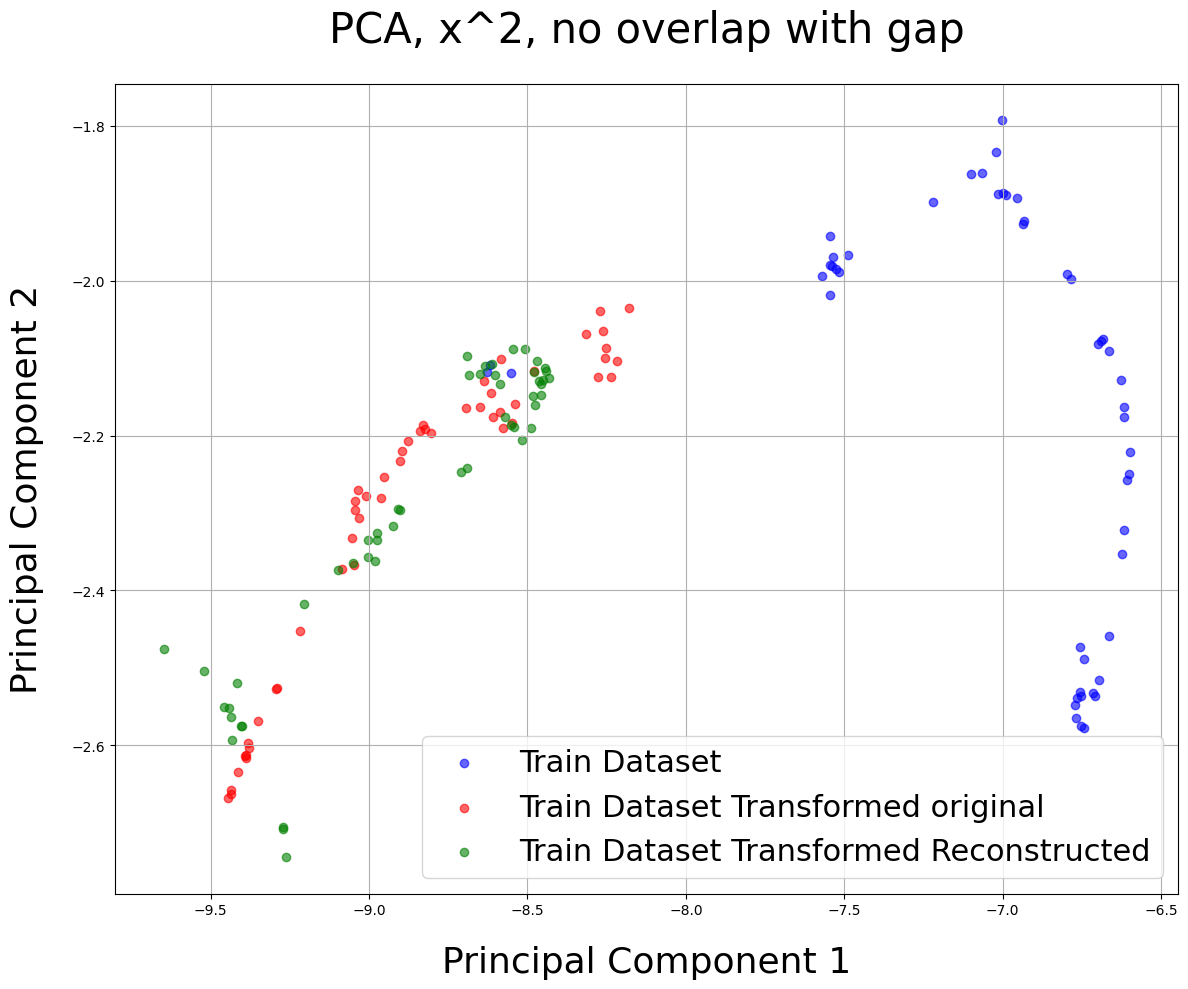

In [11]:

fig, ax = plt.subplots(figsize=(12, 10))

ax.scatter(source_emb_r[:, 0][100:], source_emb_r[:, 1][100:], c="blue", label="Train Dataset", alpha=0.6)
ax.scatter(target_emb_r[:, 0][100:], target_emb_r[:, 1][100:], c="red", label="Train Dataset Transformed original", alpha=0.6)
ax.scatter(y_pred_train[:, 0][100:], y_pred_train[:, 1][100:], c="green", label="Train Dataset Transformed Reconstructed", alpha=0.6)

'''ax.scatter(source_emb2_r[:, 0][100:], source_emb2_r[:, 1][100:], c="purple", label="Test Dataset", alpha=0.6)
ax.scatter(target_emb2_r[:, 0][100:], target_emb2_r[:, 1][100:], c="orange", label="Test Dataset Transformed original", alpha=0.6)
ax.scatter(y_pred_test[:, 0][100:], y_pred_test[:, 1][100:], c="pink", label="Test Dataset Transformed Reconstructed", alpha=0.6)
'''

# Set titles and labels (2x size) 
ax.set_title("PCA, x^2, no overlap with gap", fontsize=30, pad=30)
ax.set_xlabel("Principal Component 1", fontsize=26, labelpad=20)
ax.set_ylabel("Principal Component 2", fontsize=26, labelpad=20)
ax.legend(loc="best", fontsize=22)
ax.grid(True)

# Save and show
plt.tight_layout()
plt.savefig("/zfsauton2/home/ekaczmar/representations-in-tsfms-main/representations-in-tsfms-main/hough_transform/results_corr/pca.png", bbox_inches="tight")
plt.show()

In [7]:
def load_activations(path, model_type, num_samples, device):
    activations = extract_activations(path, model_type, num_samples, device)
    return np.mean(activations[23, :, :, :], axis=1)

In [9]:
#import umap.umap_ as umap
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

num_samples=50
model_type="moment"
output_dir="results"
device="cpu"


#path = "/zfsauton2/home/ekaczmar/representations-in-tsfms-main/representations-in-tsfms-main/hough_transform/"
path = "/mnt/c/Users/emika/OneDrive/Pulpit/Studia 4. rok/RISS//representations-in-tsfms-main/representations-in-tsfms-main/hough_transform/"
dataset1_path = os.path.join(path, "datasets/diverse_nl_transformed.parquet")
dataset2_path = os.path.join(path, "datasets2/diverse_nl_transformed_sine2.parquet")
dataset3_path = os.path.join(path, "datasets2/diverse_nl_transformed_sine3.parquet")
dataset4_path = os.path.join(path, "datasets2/diverse_nl_transformed_sine4.parquet")
dataset5_path = os.path.join(path, "datasets2/diverse_nl_transformed_sine5.parquet")

activations1 = load_activations(dataset1_path, model_type, num_samples, device)
activations2 = load_activations(dataset2_path, model_type, num_samples, device)
activations3 = load_activations(dataset3_path, model_type, num_samples, device)
activations4 = load_activations(dataset4_path, model_type, num_samples, device)
activations5 = load_activations(dataset5_path, model_type, num_samples, device)

In [22]:
dataset_path = os.path.join(path, "datasets2/diverse_nl_transformed.parquet")
dataset = load_dataset(dataset_path, type="torch", device=device)
print(dataset.shape)
avg_var = dataset[100:150,:,:].var(dim=2).mean().item()
print(f"Average Variance: {avg_var:.4f}")

torch.Size([150, 1, 512])
Average Variance: 30269466.0000


In [10]:

combined = np.concatenate([activations1, activations2, activations3, activations4, activations5], axis=0)
reducer = PCA(n_components=2)
#reducer = umap.UMAP( n_components=15,n_neighbors=10,min_dist=0.0,metric="euclidean",random_state=42)

combined_reduced = reducer.fit_transform(combined)

n = activations1.shape[0] 
reduced1 = combined_reduced[:n]
reduced2 = combined_reduced[n:2*n]
reduced3 = combined_reduced[2*n:3*n]
reduced4 = combined_reduced[3*n:4*n]
reduced5 = combined_reduced[4*n:]

'''labels = np.concatenate([
    np.zeros(activations1.shape[0]),
    np.ones(activations2.shape[0]),
    np.full(activations3.shape[0], 2),
    np.full(activations4.shape[0], 3),
    np.full(activations5.shape[0], 4),
])

# Stack activations
combined_embeddings = np.vstack([
    activations1,
    activations2,
    activations3,
    activations4,
    activations5,
])

# Multi-class LDA → 2D projection
lda = LinearDiscriminantAnalysis(n_components=2)
reduced_embeddings = lda.fit_transform(combined_embeddings, labels)

# Split back into per-class reduced embeddings
reduced1 = reduced_embeddings[labels == 0]
reduced2 = reduced_embeddings[labels == 1]
reduced3 = reduced_embeddings[labels == 2]
reduced4 = reduced_embeddings[labels == 3]
reduced5 = reduced_embeddings[labels == 4]'''


'labels = np.concatenate([\n    np.zeros(activations1.shape[0]),\n    np.ones(activations2.shape[0]),\n    np.full(activations3.shape[0], 2),\n    np.full(activations4.shape[0], 3),\n    np.full(activations5.shape[0], 4),\n])\n\n# Stack activations\ncombined_embeddings = np.vstack([\n    activations1,\n    activations2,\n    activations3,\n    activations4,\n    activations5,\n])\n\n# Multi-class LDA → 2D projection\nlda = LinearDiscriminantAnalysis(n_components=2)\nreduced_embeddings = lda.fit_transform(combined_embeddings, labels)\n\n# Split back into per-class reduced embeddings\nreduced1 = reduced_embeddings[labels == 0]\nreduced2 = reduced_embeddings[labels == 1]\nreduced3 = reduced_embeddings[labels == 2]\nreduced4 = reduced_embeddings[labels == 3]\nreduced5 = reduced_embeddings[labels == 4]'

In [11]:
#k nearesst neighbours
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


X = np.vstack([reduced1, reduced2, reduced3, reduced4, reduced5])
n = reduced1.shape[0]
y = np.array([0]*n + [1]*n + [2]*n + [3]*n + [4]*n)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Accuracy: 0.88

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.80      0.89        10
           2       0.80      0.80      0.80        10
           3       0.83      1.00      0.91        10
           4       0.80      0.80      0.80        10

    accuracy                           0.88        50
   macro avg       0.89      0.88      0.88        50
weighted avg       0.89      0.88      0.88        50


Confusion Matrix:
 [[10  0  0  0  0]
 [ 0  8  0  2  0]
 [ 0  0  8  0  2]
 [ 0  0  0 10  0]
 [ 0  0  2  0  8]]


In [12]:
#reduce to 2 if embeddinngs are higher dimensional

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Split back to match reduced1..5
n = reduced1.shape[0]
reduced1 = X_pca[0:n]
reduced2 = X_pca[n:2*n]
reduced3 = X_pca[2*n:3*n]
reduced4 = X_pca[3*n:4*n]
reduced5 = X_pca[4*n:]

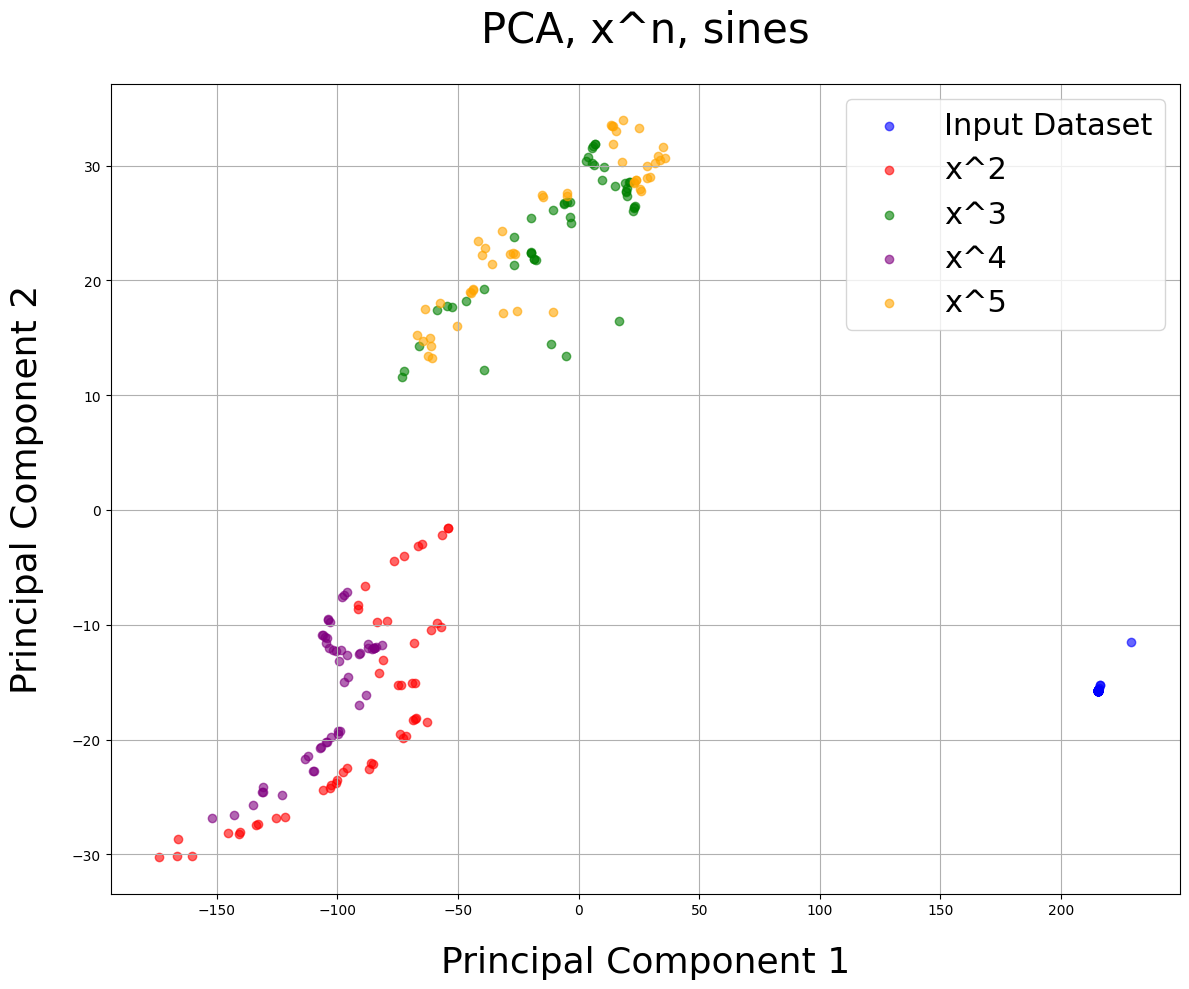

In [14]:
fig, ax = plt.subplots(figsize=(12, 10))

ax.scatter(reduced1[:, 0], reduced1[:, 1], c="blue", label="Input Dataset", alpha=0.6)
ax.scatter(reduced2[:, 0], reduced2[:, 1], c="red", label="x^2", alpha=0.6)
ax.scatter(reduced3[:, 0], reduced3[:, 1], c="green", label="x^3", alpha=0.6)
ax.scatter(reduced4[:, 0], reduced4[:, 1], c="purple", label="x^4", alpha=0.6)
ax.scatter(reduced5[:, 0], reduced5[:, 1], c="orange", label="x^5", alpha=0.6)

# Set titles and labels (2x size) 
ax.set_title("PCA, x^n, sines", fontsize=30, pad=30)
ax.set_xlabel("Principal Component 1", fontsize=26, labelpad=20)
ax.set_ylabel("Principal Component 2", fontsize=26, labelpad=20)
ax.legend(loc="best", fontsize=22)
ax.grid(True)

# Save and show
plt.tight_layout()
#plt.savefig("/zfsauton2/home/ekaczmar/representations-in-tsfms-main/representations-in-tsfms-main/hough_transform/results_corr/pca.png", bbox_inches="tight")
plt.show()